$^{87}\mathrm{Rb}$ driven on the $5S_{1/2} F=1 \rightarrow 5p_{1/2} F=1$ transition

## Define the Hyperfine Structure

In [1]:
import numpy as np

In [2]:
from maxwellbloch import hyperfine

Rb87_5s12_F1 = hyperfine.LevelF(I=1.5, J=0.5, F=1)
Rb87_5s12_F2 = hyperfine.LevelF(I=1.5, J=0.5, F=2)  # Needed for decay

Rb87_5p12_F1 = hyperfine.LevelF(I=1.5, J=0.5, F=1)

atom1e = hyperfine.Atom1e(element="Rb", isotope="87")

atom1e.add_F_level(Rb87_5s12_F1)
atom1e.add_F_level(Rb87_5s12_F2)
atom1e.add_F_level(Rb87_5p12_F1)

In [3]:
NUM_STATES = atom1e.get_num_mF_levels()
print(NUM_STATES)

11


In [4]:
ENERGIES = atom1e.get_energies()
print(ENERGIES)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [5]:
# Tune to be on resonance with the F1 -> F1 transition
DETUNING = 0
print(DETUNING)

0


In [6]:
FIELD_CHANNELS = atom1e.get_coupled_levels(F_level_idxs_a=(0,), F_level_idxs_b=(2,))
print(FIELD_CHANNELS)

[[0, 8], [0, 9], [0, 10], [1, 8], [1, 9], [1, 10], [2, 8], [2, 9], [2, 10]]


In [7]:
q = 1  # Field polarisation
FIELD_FACTORS = atom1e.get_clebsch_hf_factors(
    F_level_idxs_a=(0,), F_level_idxs_b=(2,), q=q
)
print(FIELD_FACTORS)
print(np.sum(FIELD_FACTORS**2))

[ 0.          0.          0.          0.28867513 -0.         -0.
  0.          0.28867513  0.        ]
0.16666666666666657


In [8]:
DECAY_CHANNELS = atom1e.get_coupled_levels(F_level_idxs_a=(0, 1), F_level_idxs_b=(2,))
print(DECAY_CHANNELS)

[[0, 8], [0, 9], [0, 10], [1, 8], [1, 9], [1, 10], [2, 8], [2, 9], [2, 10], [3, 8], [3, 9], [3, 10], [4, 8], [4, 9], [4, 10], [5, 8], [5, 9], [5, 10], [6, 8], [6, 9], [6, 10], [7, 8], [7, 9], [7, 10]]


In [9]:
DECAY_FACTORS = atom1e.get_decay_factors(F_level_idxs_a=(0, 1), F_level_idxs_b=(2,))
print(DECAY_FACTORS)

[ 0.28867513 -0.28867513  0.          0.28867513 -0.         -0.28867513
  0.          0.28867513 -0.28867513  0.70710678  0.          0.
  0.5         0.5        -0.          0.28867513  0.57735027  0.28867513
 -0.          0.5         0.5         0.          0.          0.70710678]


In [10]:
INITIAL_STATE = (
    [0.5 / 3.0] * 3  # s12_F1
    + [0.5 / 5.0] * 5  # s12_F2
    + [0.0] * 3
)  # p12_F1
print(INITIAL_STATE)

[0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0]


In [11]:
mb_solve_json = """
{{
  "atom": {{
    "decays": [
      {{
        "channels": {decay_channels},
        "rate": 1.0,
        "factors": {decay_factors}
      }}
    ],
    "energies": {energies},
    "fields": [
      {{
        "coupled_levels": {field_channels},
        "factors": {field_factors},
        "detuning": {detuning},
        "detuning_positive": true,
        "label": "probe",
        "rabi_freq": 1e-3,
        "rabi_freq_t_args": {{
          "ampl": 1.0,
          "centre": 0.0,
          "fwhm": 1.0
        }},
        "rabi_freq_t_func": "gaussian"
      }}
    ],
    "num_states": {num_states},
    "initial_state": {initial_state}
  }},
  "t_min": -2.0,
  "t_max": 10.0,
  "t_steps": 100,
  "z_min": -0.2,
  "z_max": 1.2,
  "z_steps": 100,
  "interaction_strengths": [
    1.0e2
  ],
  "savefile": "mbs-Rb87_5s12_5p12_F11_q1-weak-pulse-decay"
}}
""".format(
    num_states=NUM_STATES,
    energies=ENERGIES,
    initial_state=INITIAL_STATE,
    detuning=DETUNING,
    field_channels=FIELD_CHANNELS,
    field_factors=FIELD_FACTORS.tolist(),
    decay_channels=DECAY_CHANNELS,
    decay_factors=DECAY_FACTORS.tolist(),
)

In [12]:
from maxwellbloch import mb_solve

mbs = mb_solve.MBSolve().from_json_str(mb_solve_json)

In [13]:
Omegas_zt, states_zt = mbs.mbsolve(recalc=False)

In [14]:
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns

sns.set_style("dark")

import numpy as np

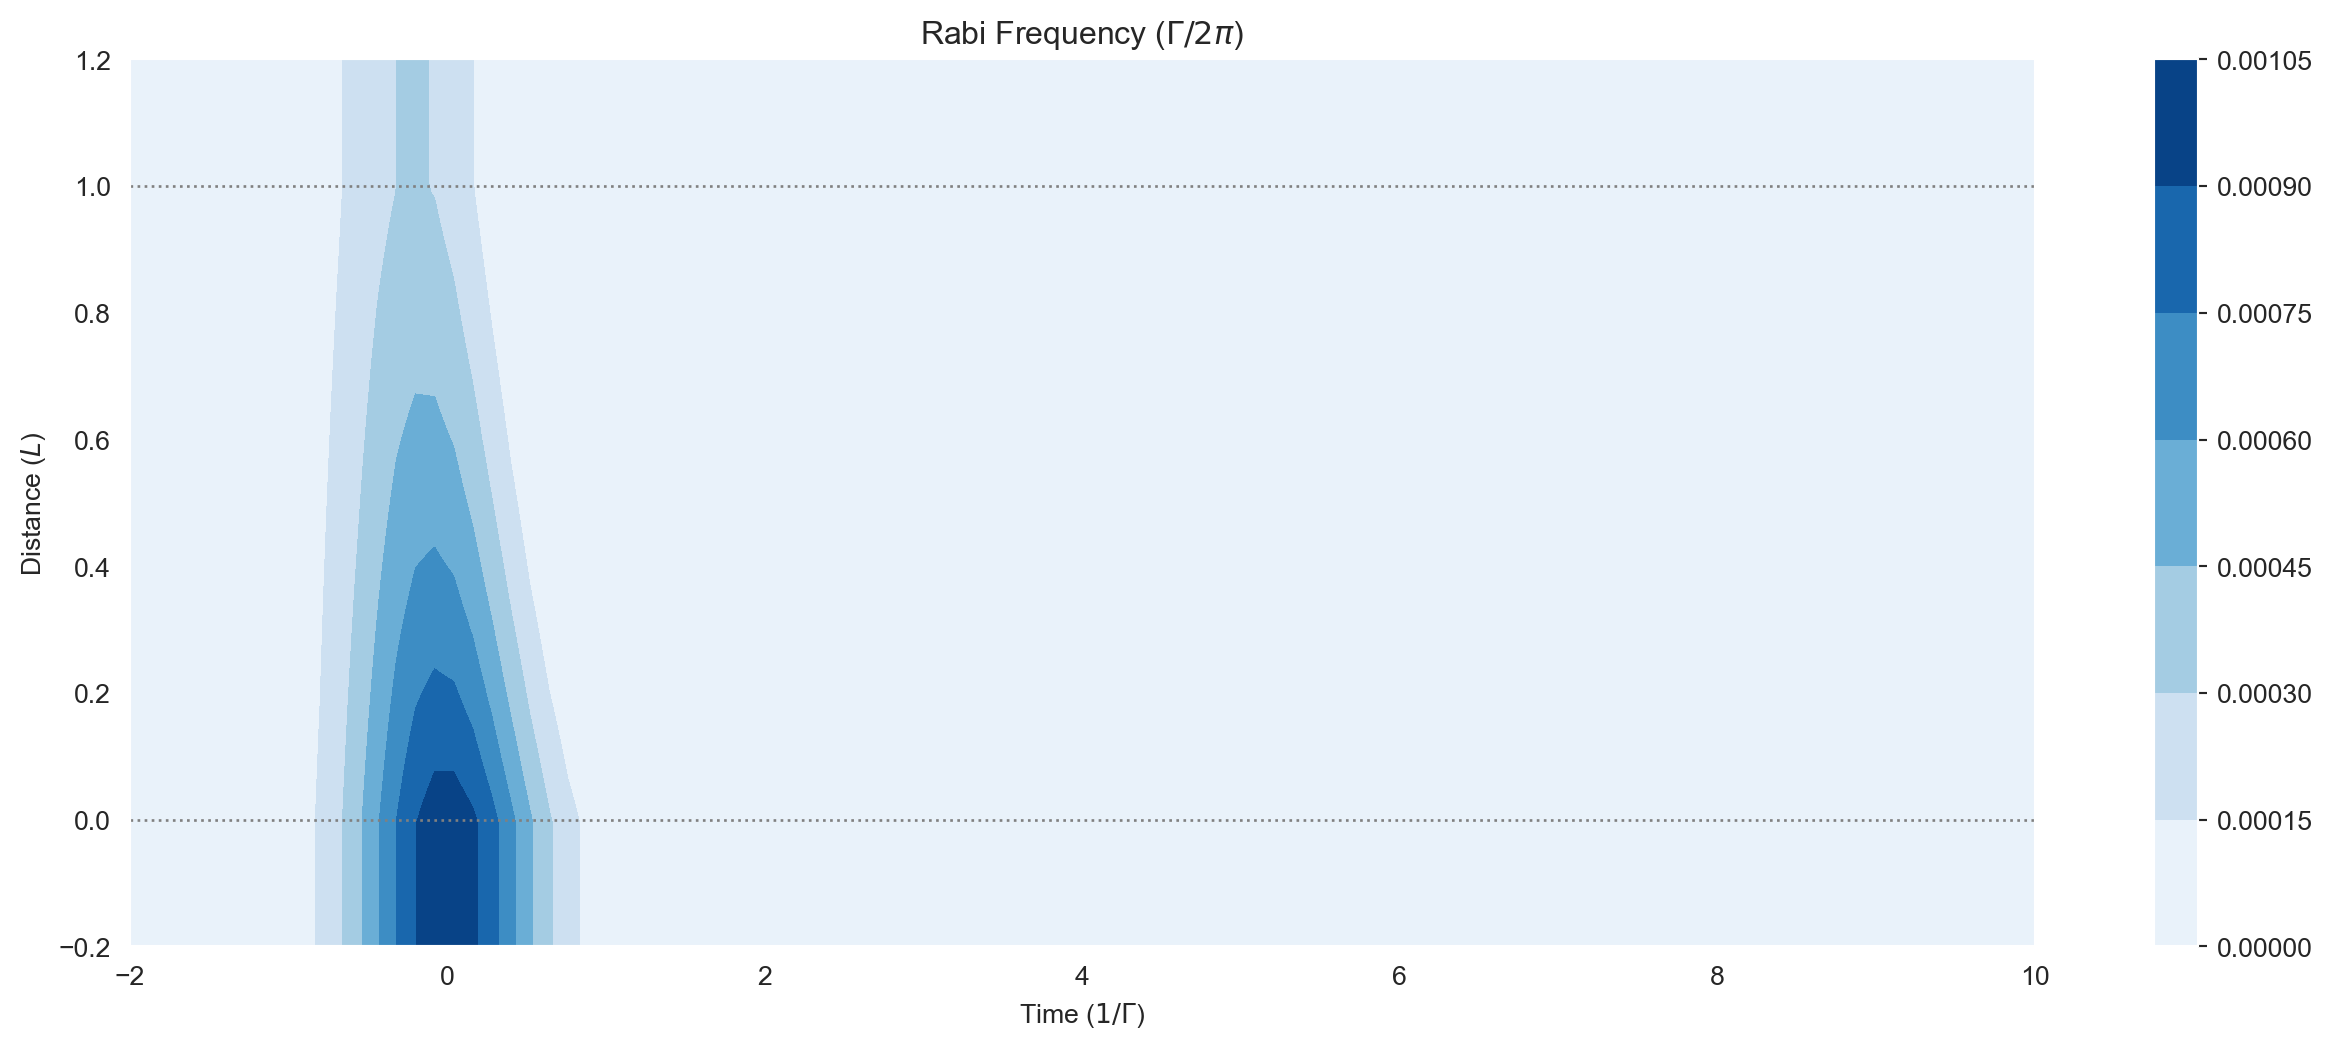

In [15]:
fig = plt.figure(1, figsize=(16, 6))
ax = fig.add_subplot(111)
# cmap_range = np.linspace(0.0, 1.0e-3, 11)
cf = ax.contourf(
    mbs.tlist,
    mbs.zlist,
    np.abs(mbs.Omegas_zt[0] / (2 * np.pi)),
    #                  cmap_range,
    cmap=plt.cm.Blues,
)
ax.set_title(r"Rabi Frequency ($\Gamma / 2\pi $)")
ax.set_xlabel(r"Time ($1/\Gamma$)")
ax.set_ylabel("Distance ($L$)")
for y in [0.0, 1.0]:
    ax.axhline(y, c="grey", lw=1.0, ls="dotted")
plt.colorbar(cf);

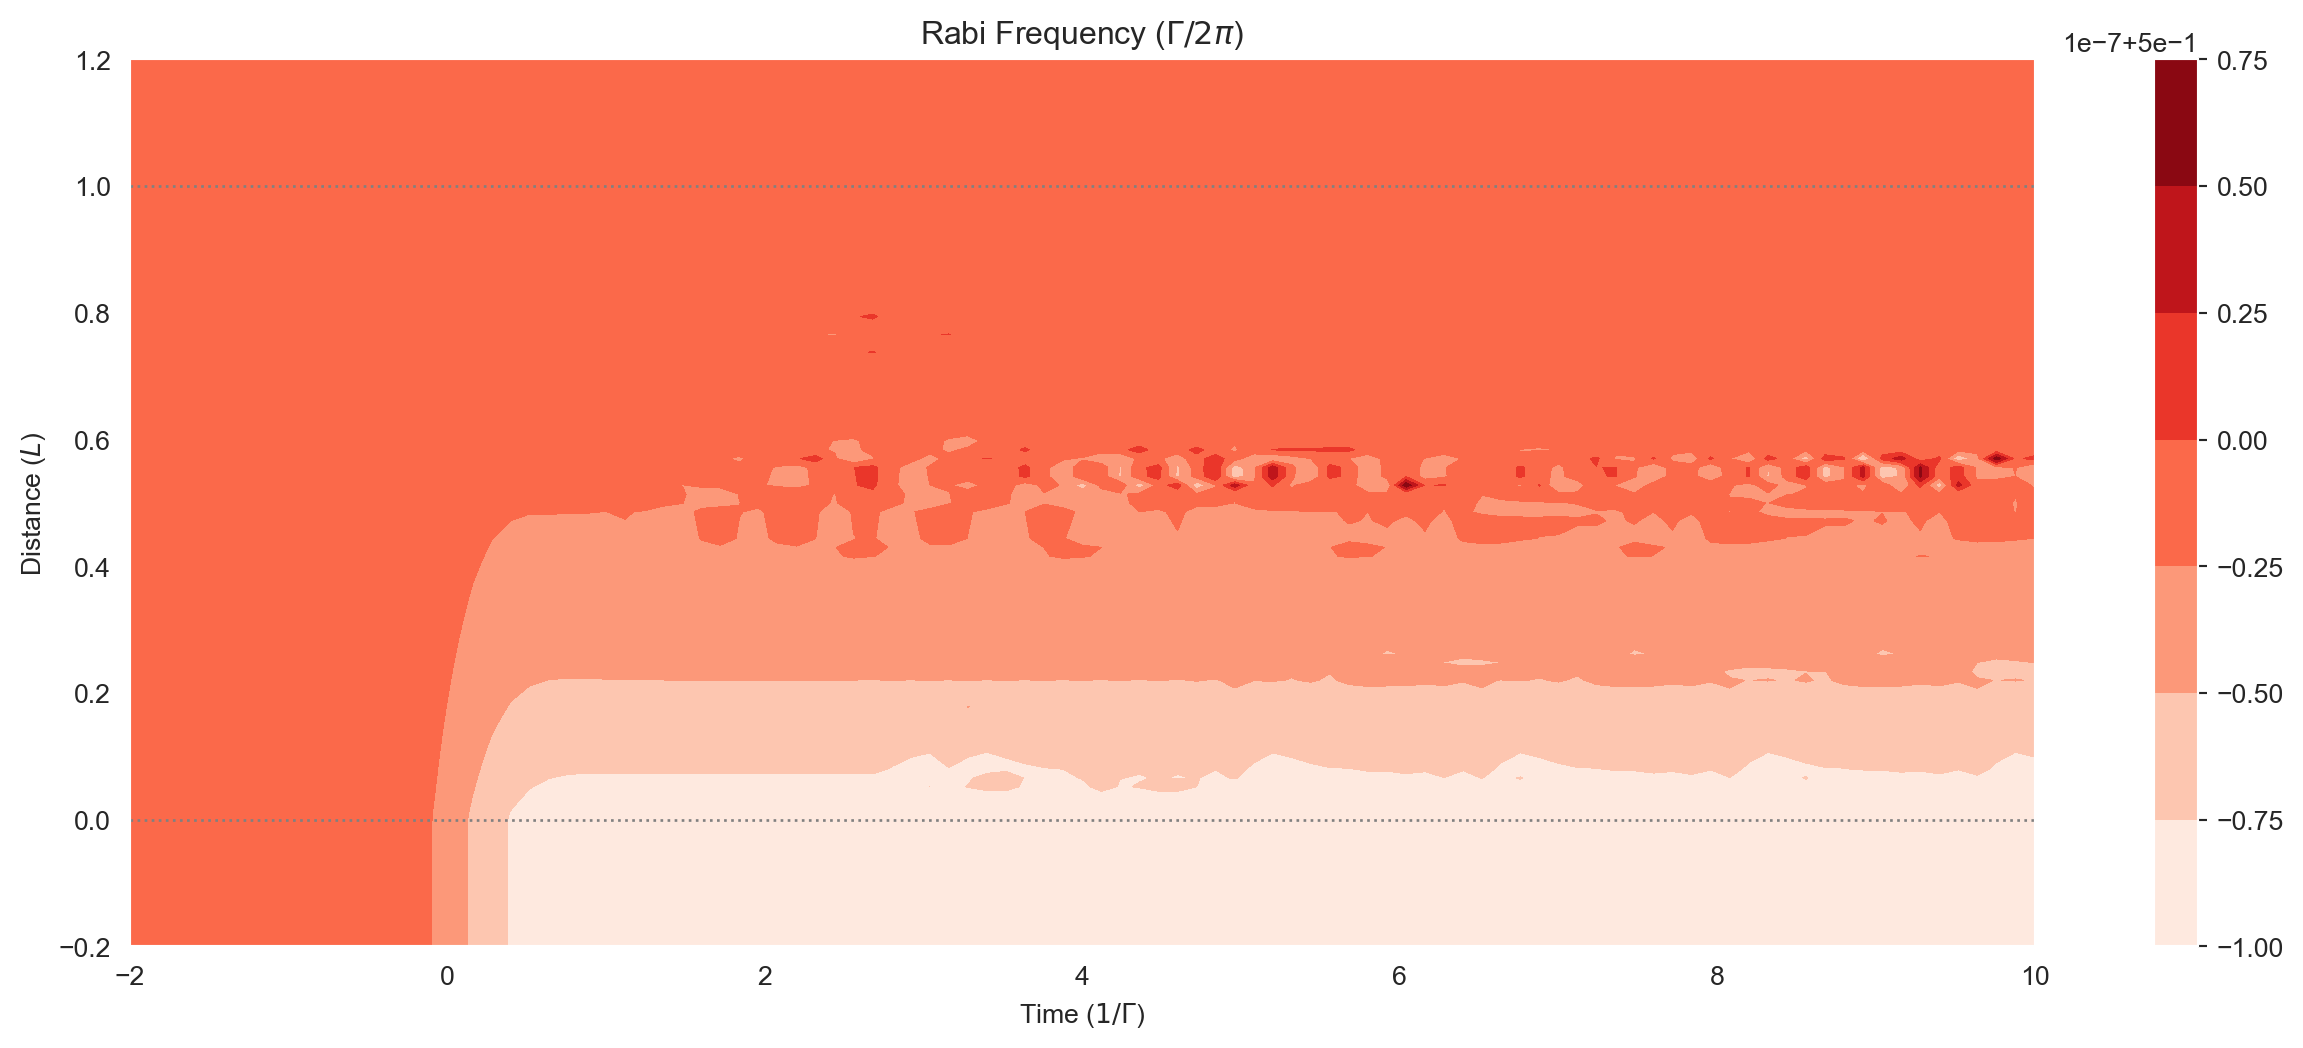

In [16]:
fig = plt.figure(1, figsize=(16, 6))
ax = fig.add_subplot(111)
# cmap_range = np.linspace(0.0, 1.0e-3, 11)
cf = ax.contourf(
    mbs.tlist,
    mbs.zlist,
    np.abs(mbs.populations_field(0, upper=False)),
    #                  cmap_range,
    cmap=plt.cm.Reds,
)
ax.set_title(r"Rabi Frequency ($\Gamma / 2\pi $)")
ax.set_xlabel(r"Time ($1/\Gamma$)")
ax.set_ylabel("Distance ($L$)")
for y in [0.0, 1.0]:
    ax.axhline(y, c="grey", lw=1.0, ls="dotted")
plt.colorbar(cf);

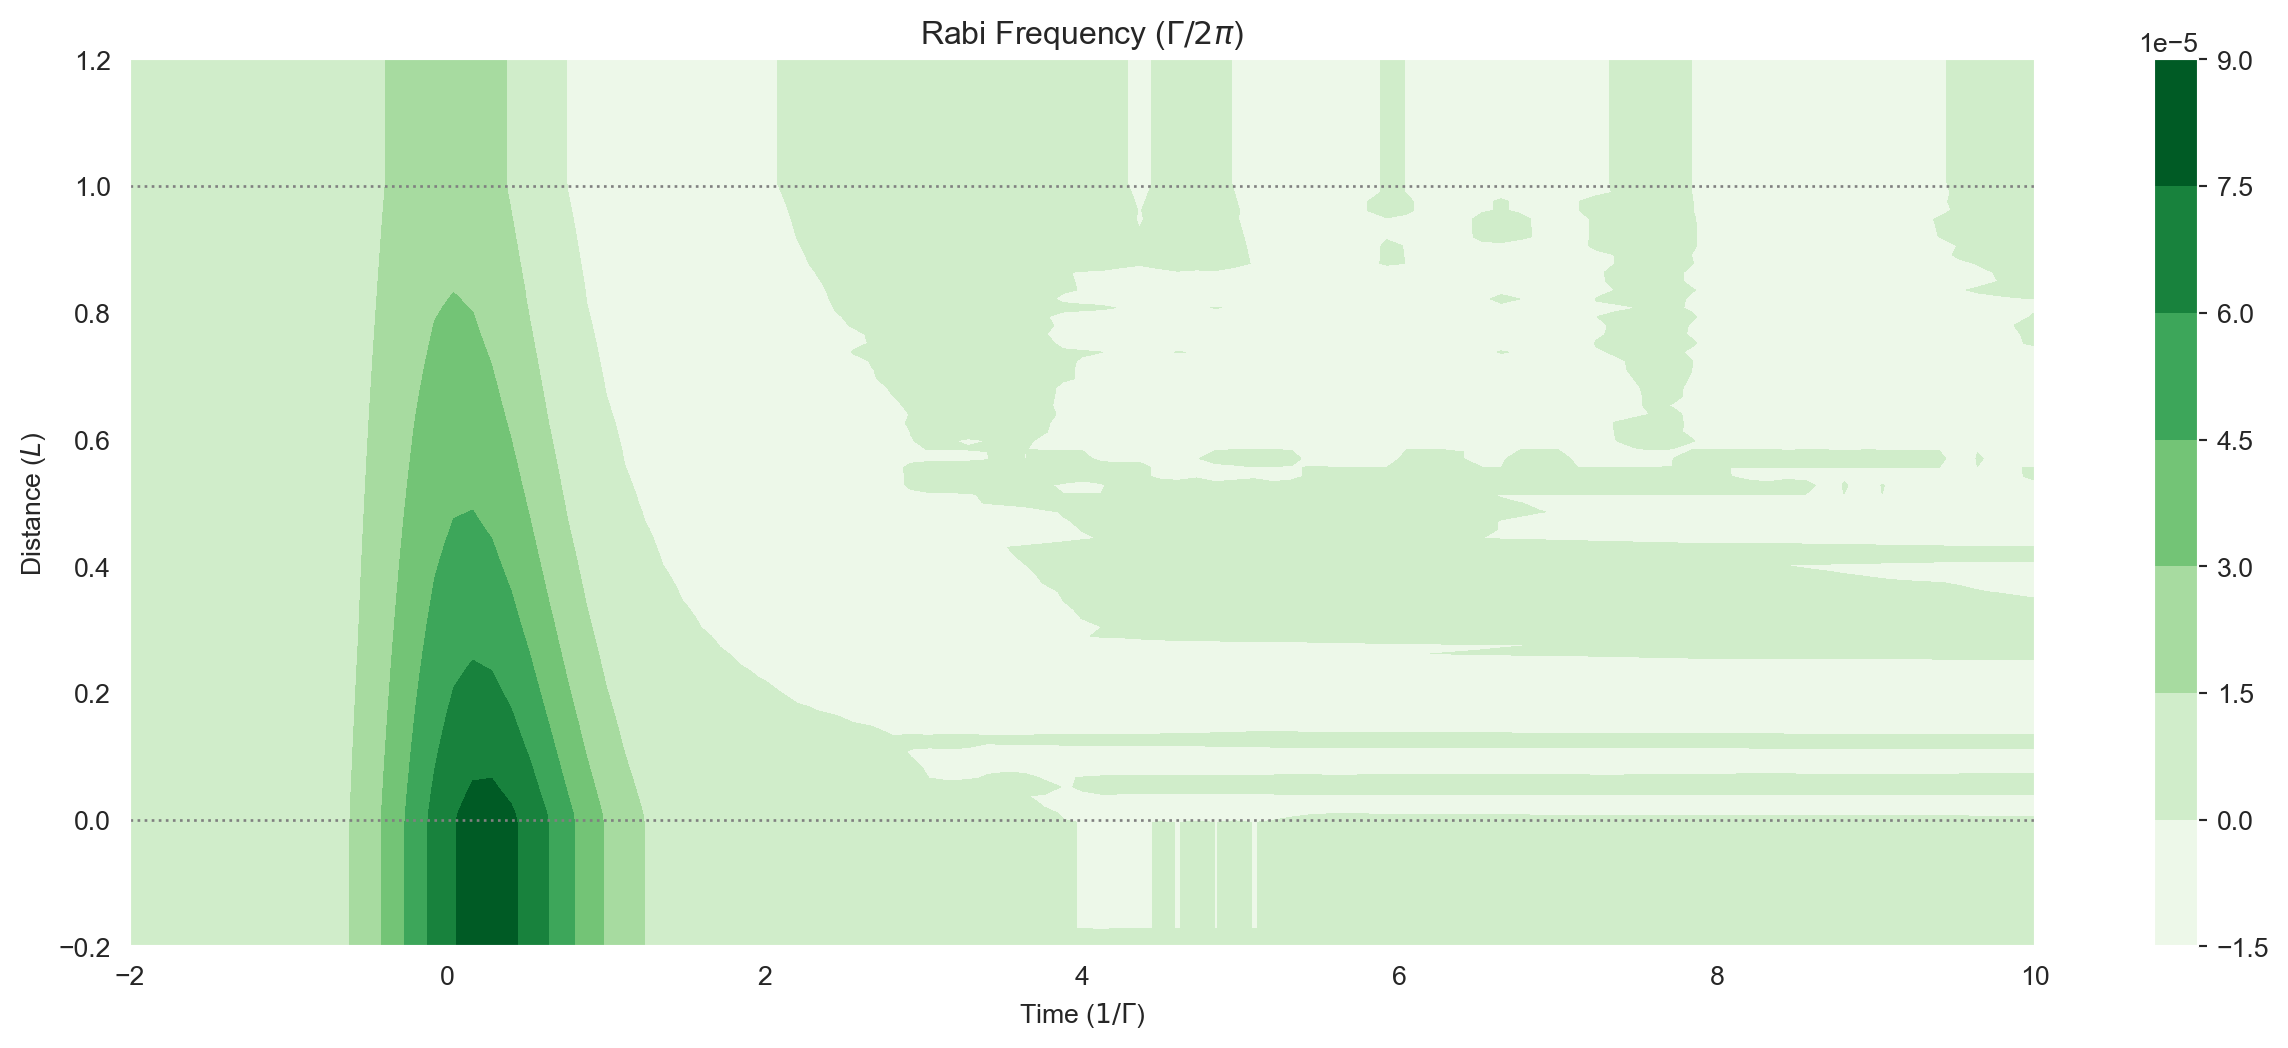

In [17]:
fig = plt.figure(1, figsize=(16, 6))
ax = fig.add_subplot(111)
# cmap_range = np.linspace(0.0, 1.0e-3, 11)
cf = ax.contourf(
    mbs.tlist,
    mbs.zlist,
    np.imag(mbs.coherences_field(0)),
    #                  cmap_range,
    cmap=plt.cm.Greens,
)
ax.set_title(r"Rabi Frequency ($\Gamma / 2\pi $)")
ax.set_xlabel(r"Time ($1/\Gamma$)")
ax.set_ylabel("Distance ($L$)")
for y in [0.0, 1.0]:
    ax.axhline(y, c="grey", lw=1.0, ls="dotted")
plt.colorbar(cf);